# Introduction to Natural Language Processing (NLP)
### NLP Engineering Bootcamp: From Basics to Advanced

This notebook is the hands-on companion to `nlp_intro_theory.md`. It uses only `numpy`, `pandas`, `matplotlib`, `scikit-learn` and the Python standard library, so it runs anywhere without downloading extra data. Optional cells for NLTK, spaCy and Hugging Face are guarded, so they are skipped automatically if those libraries are not installed.

**Contents**
1. Text cleaning
2. Tokenization (word, sentence, character, and a tiny BPE subword demo)
3. Stop-word removal (and why negation matters)
4. Stemming vs. lemmatization
5. Bag of Words and N-grams
6. TF-IDF (from scratch and with scikit-learn)
7. Cosine similarity and a mini search engine
8. Word embeddings intuition (co-occurrence + SVD)
9. Text classification: sentiment analysis pipeline
10. N-gram language model and perplexity
11. Topic modeling (NMF)
12. Self-attention from scratch (the core of Transformers)
13. Optional: NLTK, spaCy and Hugging Face


In [1]:
import re
import math
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD, NMF

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Text Cleaning

Real text is messy: URLs, HTML, emojis, extra spaces, mixed case. Cleaning makes the text consistent before we tokenize it.


In [2]:
raw_text = """<p>OMG!!! I LOVED the new phone 😍😍 Check it out at https://example.com/review  
It's sooo good... battery lasts 2 days!!! Don't buy anything else. #bestphone @techguy</p>"""

CONTRACTIONS = {"don't": "do not", "it's": "it is", "can't": "cannot", "won't": "will not", "i'm": "i am"}

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)              # remove HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'[@#]\w+', ' ', text)            # remove mentions and hashtags
    text = text.lower()
    for k, v in CONTRACTIONS.items():                # expand contractions
        text = text.replace(k, v)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)      # sooo -> soo (limit repeated characters)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)         # remove punctuation, digits kept, emojis dropped
    text = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    return text

print('RAW  :', raw_text.replace('\n', ' '))
print('CLEAN:', clean_text(raw_text))


RAW  : <p>OMG!!! I LOVED the new phone 😍😍 Check it out at https://example.com/review   It's sooo good... battery lasts 2 days!!! Don't buy anything else. #bestphone @techguy</p>
CLEAN: omg i loved the new phone check it out at it is soo good battery lasts 2 days do not buy anything else


## 2. Tokenization

Tokenization splits text into units (tokens). We'll look at word, sentence and character tokenization, then build a tiny **Byte-Pair Encoding (BPE)** subword tokenizer to see how modern models like GPT and BERT handle rare words.


In [3]:
paragraph = "NLP is amazing. It powers chatbots, translation, and search! Dr. Rao said it's the future."

# Word tokenization (simple regex: words or single punctuation marks)
word_tokens = re.findall(r"\w+(?:'\w+)?|[^\w\s]", paragraph)
print('Word tokens     :', word_tokens)

# Sentence tokenization (naive: split after . ! ? followed by a space and a capital letter)
sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', paragraph)
print('Sentence tokens :', sentences)

# Character tokenization
print('Char tokens     :', list("NLP"))


Word tokens     : ['NLP', 'is', 'amazing', '.', 'It', 'powers', 'chatbots', ',', 'translation', ',', 'and', 'search', '!', 'Dr', '.', 'Rao', 'said', "it's", 'the', 'future', '.']
Sentence tokens : ['NLP is amazing.', 'It powers chatbots, translation, and search!', 'Dr.', "Rao said it's the future."]
Char tokens     : ['N', 'L', 'P']


Notice that the naive sentence splitter wrongly breaks after "Dr." That is why libraries like NLTK and spaCy ship trained sentence tokenizers.

### Tiny BPE (subword) tokenizer from scratch

BPE starts with characters and repeatedly **merges the most frequent adjacent pair** into a new token.


In [4]:
def get_pair_counts(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for a, b in zip(symbols, symbols[1:]):
            pairs[(a, b)] += freq
    return pairs

def merge_pair(pair, vocab):
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word, freq in vocab.items():
        new_vocab[word.replace(bigram, replacement)] = freq
    return new_vocab

corpus_words = ['low'] * 5 + ['lower'] * 2 + ['newest'] * 6 + ['widest'] * 3
vocab = Counter(' '.join(list(w)) + ' </w>' for w in corpus_words)
print('Initial vocab:', dict(vocab))

merges = []
for step in range(8):
    pairs = get_pair_counts(vocab)
    if not pairs:
        break
    best = max(pairs, key=pairs.get)
    vocab = merge_pair(best, vocab)
    merges.append(best)
    print(f'Merge {step + 1}: {best} -> {"".join(best)}')

print('\nFinal vocab:', dict(vocab))


Initial vocab: {'l o w </w>': 5, 'l o w e r </w>': 2, 'n e w e s t </w>': 6, 'w i d e s t </w>': 3}
Merge 1: ('e', 's') -> es
Merge 2: ('es', 't') -> est
Merge 3: ('est', '</w>') -> est</w>
Merge 4: ('l', 'o') -> lo
Merge 5: ('lo', 'w') -> low
Merge 6: ('n', 'e') -> ne
Merge 7: ('ne', 'w') -> new
Merge 8: ('new', 'est</w>') -> newest</w>

Final vocab: {'low </w>': 5, 'low e r </w>': 2, 'newest</w>': 6, 'w i d est</w>': 3}


After a few merges, frequent chunks such as `est</w>` and `low` become single tokens, while rare words are still representable as combinations of smaller pieces. That is how subword tokenizers avoid "unknown word" problems.


## 3. Stop-Word Removal

Stop words are very common words with little meaning on their own. Removing them shrinks the vocabulary, but it can be **dangerous** for tasks like sentiment analysis.


In [5]:
STOP_WORDS = set("""a an the is are was were be been am i me my we our you your he she it its they them
this that these those of in on at to for from with and or but so as by not no do does did have has had will would can""".split())

def remove_stopwords(tokens, stop_words=STOP_WORDS):
    return [t for t in tokens if t not in stop_words]

sent = "the movie was not good and the acting was not great"
tokens = sent.split()
print('Original tokens      :', tokens)
print('After stop-word removal:', remove_stopwords(tokens))


Original tokens      : ['the', 'movie', 'was', 'not', 'good', 'and', 'the', 'acting', 'was', 'not', 'great']
After stop-word removal: ['movie', 'good', 'acting', 'great']


Look at the result: removing `not` changes "not good" into "good", which **flips the sentiment**. For sentiment tasks, keep negation words (or use n-grams that preserve them). Always match preprocessing to the task.


## 4. Stemming vs. Lemmatization

- **Stemming** chops suffixes with rules (fast, may produce non-words).
- **Lemmatization** maps a word to its dictionary base form (slower, more accurate).

Below is a simplified rule-based stemmer and a tiny dictionary lemmatizer to show the difference. In real projects you would use NLTK's `PorterStemmer` / `WordNetLemmatizer` or spaCy.


In [6]:
def simple_stem(word):
    for suffix in ['ingly', 'edly', 'ing', 'ed', 'ies', 'es', 's', 'ly']:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            stem = word[:-len(suffix)]
            if suffix == 'ies':
                stem += 'i'
            return stem
    return word

LEMMA_DICT = {'studies': 'study', 'studying': 'study', 'studied': 'study', 'better': 'good',
              'running': 'run', 'ran': 'run', 'mice': 'mouse', 'was': 'be', 'were': 'be',
              'feet': 'foot', 'cities': 'city'}

def simple_lemmatize(word):
    return LEMMA_DICT.get(word, word)

words = ['studies', 'studying', 'better', 'running', 'ran', 'mice', 'cities', 'happily']
df = pd.DataFrame({'word': words,
                   'stem': [simple_stem(w) for w in words],
                   'lemma': [simple_lemmatize(w) for w in words]})
df


,word,stem,lemma
0,studies,studi,study
1,studying,study,study
2,better,better,good
3,running,runn,run
4,ran,ran,run
5,mice,mice,mouse
6,cities,citi,city
7,happily,happi,happily


Stemming turns "studies" into `studi` (not a real word) and cannot handle irregular forms such as "ran" or "mice". Lemmatization gets `study`, `run`, `mouse`, but needs a dictionary.


## 5. Bag of Words and N-grams

Bag of Words represents each document as a vector of word counts. N-grams add short word sequences so that some local order (like "not good") is preserved.


In [7]:
docs = [
    "the food was good",
    "the food was not good",
    "the service was very slow",
    "great food and great service",
]

cv = CountVectorizer()
bow = cv.fit_transform(docs)
pd.DataFrame(bow.toarray(), columns=cv.get_feature_names_out(), index=[f'doc{i}' for i in range(len(docs))])


,and,food,good,great,not,service,slow,the,very,was
doc0,0,1,1,0,0,0,0,1,0,1
doc1,0,1,1,0,1,0,0,1,0,1
doc2,0,0,0,0,0,1,1,1,1,1
doc3,1,1,0,2,0,1,0,0,0,0


In [8]:
cv_ngram = CountVectorizer(ngram_range=(1, 2))   # unigrams + bigrams
bow2 = cv_ngram.fit_transform(docs)
print('Vocabulary size (unigrams only)      :', len(cv.get_feature_names_out()))
print('Vocabulary size (unigrams + bigrams) :', len(cv_ngram.get_feature_names_out()))
print('\nSome bigrams:', [f for f in cv_ngram.get_feature_names_out() if ' ' in f][:10])


Vocabulary size (unigrams only)      : 10
Vocabulary size (unigrams + bigrams) : 23

Some bigrams: ['and great', 'food and', 'food was', 'great food', 'great service', 'not good', 'service was', 'the food', 'the service', 'very slow']


## 6. TF-IDF

TF-IDF down-weights words that appear in many documents and up-weights distinctive words.

```
TF(t, d) = count(t in d) / len(d)
IDF(t)   = log(N / df(t))
```

First from scratch, then with scikit-learn.


In [9]:
def tfidf_from_scratch(documents):
    tokenized = [d.split() for d in documents]
    N = len(tokenized)
    vocab = sorted(set(w for doc in tokenized for w in doc))
    df_counts = {w: sum(1 for doc in tokenized if w in doc) for w in vocab}
    idf = {w: math.log(N / df_counts[w]) for w in vocab}

    matrix = np.zeros((N, len(vocab)))
    for i, doc in enumerate(tokenized):
        counts = Counter(doc)
        for j, w in enumerate(vocab):
            tf = counts[w] / len(doc)
            matrix[i, j] = tf * idf[w]
    return pd.DataFrame(matrix, columns=vocab, index=[f'doc{i}' for i in range(N)]), idf

tfidf_df, idf = tfidf_from_scratch(docs)
print('IDF values (higher = rarer across documents):')
print({k: round(v, 2) for k, v in sorted(idf.items(), key=lambda x: -x[1])})
tfidf_df.round(3)


IDF values (higher = rarer across documents):
{'and': 1.39, 'great': 1.39, 'not': 1.39, 'slow': 1.39, 'very': 1.39, 'good': 0.69, 'service': 0.69, 'food': 0.29, 'the': 0.29, 'was': 0.29}


,and,food,good,great,not,service,slow,the,very,was
doc0,0.000,0.072,0.173,0.000,0.000,0.000,0.000,0.072,0.000,0.072
doc1,0.000,0.058,0.139,0.000,0.277,0.000,0.000,0.058,0.000,0.058
doc2,0.000,0.000,0.000,0.000,0.000,0.139,0.277,0.058,0.277,0.058
doc3,0.277,0.058,0.000,0.555,0.000,0.139,0.000,0.000,0.000,0.000


In [10]:
tv = TfidfVectorizer()            # note: sklearn uses a smoothed IDF and L2 normalization
X_tfidf = tv.fit_transform(docs)
pd.DataFrame(X_tfidf.toarray(), columns=tv.get_feature_names_out(),
             index=[f'doc{i}' for i in range(len(docs))]).round(3)


,and,food,good,great,not,service,slow,the,very,was
doc0,0.000,0.470,0.581,0.000,0.000,0.000,0.000,0.470,0.000,0.470
doc1,0.000,0.378,0.468,0.000,0.593,0.000,0.000,0.378,0.000,0.378
doc2,0.000,0.000,0.000,0.000,0.000,0.425,0.539,0.344,0.539,0.344
doc3,0.407,0.260,0.000,0.815,0.000,0.321,0.000,0.000,0.000,0.000


Values differ slightly from the scratch version because scikit-learn uses a smoothed IDF and normalizes each row, but the idea is identical: common words such as "the" and "was" get low weight, while distinctive words such as "slow" and "great" get high weight.


## 7. Cosine Similarity and a Mini Search Engine

Cosine similarity measures the angle between two vectors, which makes it independent of document length. With TF-IDF vectors it gives us a simple search engine.


In [11]:
corpus = [
    "Python is a popular programming language for data science and machine learning",
    "Machine learning models learn patterns from data",
    "The cat sat on the mat and looked at the birds",
    "Natural language processing lets computers understand human language",
    "Dogs and cats are common household pets",
    "Deep learning is a subset of machine learning using neural networks",
]

search_vec = TfidfVectorizer(stop_words='english')
doc_matrix = search_vec.fit_transform(corpus)

def search(query, top_k=3):
    q = search_vec.transform([query])
    sims = cosine_similarity(q, doc_matrix).ravel()
    ranked = sims.argsort()[::-1][:top_k]
    return [(round(float(sims[i]), 3), corpus[i]) for i in ranked]

for q in ["learning from data with neural networks", "pets like cats"]:
    print(f'Query: {q!r}')
    for score, doc in search(q):
        print(f'   {score:.3f}  {doc}')
    print()


Query: 'learning from data with neural networks'
   0.613  Deep learning is a subset of machine learning using neural networks
   0.301  Machine learning models learn patterns from data
   0.258  Python is a popular programming language for data science and machine learning

Query: 'pets like cats'
   0.632  Dogs and cats are common household pets
   0.000  Deep learning is a subset of machine learning using neural networks
   0.000  Natural language processing lets computers understand human language



## 8. Word Embeddings Intuition (Co-occurrence + SVD)

Word2Vec and GloVe are built on the **distributional hypothesis**: words that appear in similar contexts have similar meanings. We can see this with a tiny example: build a word-word co-occurrence matrix and compress it with SVD (this is essentially LSA). The resulting dense vectors place similar words close together.


In [12]:
sentences_emb = [
    "king rules the kingdom", "queen rules the kingdom", "king loves the queen",
    "man works in the city", "woman works in the city", "man loves the woman",
    "dog chases the cat", "cat chases the mouse", "dog loves the bone",
    "the prince is a young king", "the princess is a young queen",
    "boy is a young man", "girl is a young woman",
]

tokens_list = [s.split() for s in sentences_emb]
vocab_emb = sorted(set(w for s in tokens_list for w in s))
w2i = {w: i for i, w in enumerate(vocab_emb)}

window = 2
cooc = np.zeros((len(vocab_emb), len(vocab_emb)))
for sent in tokens_list:
    for i, w in enumerate(sent):
        for j in range(max(0, i - window), min(len(sent), i + window + 1)):
            if i != j:
                cooc[w2i[w], w2i[sent[j]]] += 1

# Positive PMI transformation (a standard improvement over raw counts)
total = cooc.sum()
row = cooc.sum(axis=1, keepdims=True)
col = cooc.sum(axis=0, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log((cooc * total) / (row * col))
ppmi = np.nan_to_num(np.maximum(pmi, 0), nan=0.0, posinf=0.0, neginf=0.0)

svd = TruncatedSVD(n_components=5, random_state=0)
embeddings = svd.fit_transform(ppmi)

def most_similar(word, top_k=4):
    sims = cosine_similarity(embeddings[w2i[word]].reshape(1, -1), embeddings).ravel()
    order = sims.argsort()[::-1]
    return [(vocab_emb[i], round(float(sims[i]), 2)) for i in order if vocab_emb[i] != word][:top_k]

for w in ['king', 'man', 'dog']:
    print(w, '->', most_similar(w))


king -> [('queen', 1.0), ('kingdom', 0.93), ('bone', 0.93), ('dog', 0.84)]
man -> [('woman', 1.0), ('city', 0.94), ('works', 0.86), ('in', 0.8)]
dog -> [('mouse', 0.97), ('cat', 0.97), ('kingdom', 0.97), ('bone', 0.92)]


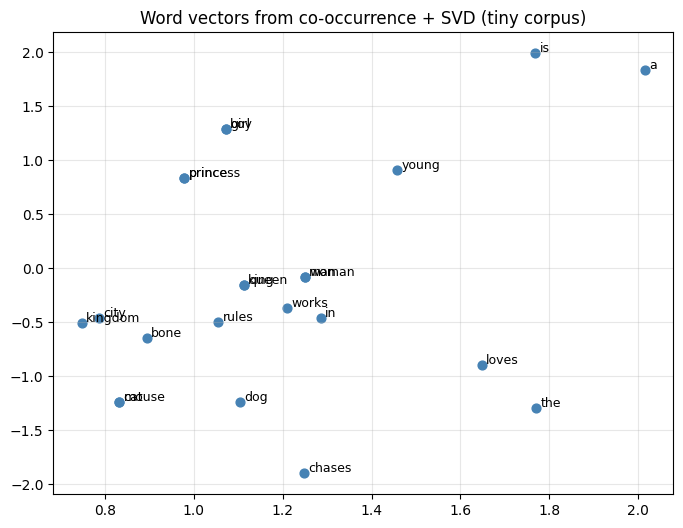

In [13]:
# 2D view of the embedding space
pts = TruncatedSVD(n_components=2, random_state=0).fit_transform(ppmi)
plt.figure(figsize=(8, 6))
plt.scatter(pts[:, 0], pts[:, 1], s=40, color='steelblue')
for w, (x, y) in zip(vocab_emb, pts):
    plt.annotate(w, (x + 0.01, y + 0.01), fontsize=9)
plt.title('Word vectors from co-occurrence + SVD (tiny corpus)')
plt.grid(alpha=0.3)
plt.show()


With such a tiny corpus the geometry is rough, but you can already see the principle. With billions of words, methods like Word2Vec learn embeddings where analogies like `king - man + woman ~ queen` emerge. Their limitation is that each word gets only **one** vector, regardless of context, which contextual models (BERT, GPT) fix.


## 9. Text Classification: Sentiment Analysis Pipeline

We'll build the classic baseline: **TF-IDF + linear model**, evaluated with precision, recall and F1. Always build this baseline before reaching for heavier models.


In [14]:
# Build a synthetic but varied sentiment dataset from templates, so that the sentiment
# words (not repeated sentence skeletons) carry the signal. Real projects use real data.
rng = np.random.RandomState(0)
nouns = ['movie', 'phone', 'food', 'service', 'book', 'hotel', 'laptop', 'story', 'app', 'delivery', 'camera', 'show']
pos_adj = ['great', 'excellent', 'fantastic', 'wonderful', 'amazing', 'superb', 'brilliant', 'lovely']
neg_adj = ['terrible', 'awful', 'horrible', 'boring', 'disappointing', 'poor', 'dreadful', 'useless']
pos_verb = ['loved', 'enjoyed', 'adored', 'liked']
neg_verb = ['hated', 'disliked', 'regretted', 'despised']
fillers = ['honestly', 'overall', 'in my opinion', 'to be fair', 'frankly', 'today', 'this week']

def make_sentence(label):
    n = rng.choice(nouns)
    f = rng.choice(fillers)
    adj = rng.choice(pos_adj if label == 1 else neg_adj)
    verb = rng.choice(pos_verb if label == 1 else neg_verb)
    neg_form = rng.rand() < 0.2            # 20% use negation: "not <opposite adjective>"
    if neg_form:
        opp = rng.choice(neg_adj if label == 1 else pos_adj)
        core = f'the {n} was not {opp}'
    else:
        core = rng.choice([f'the {n} was {adj}', f'i {verb} the {n}', f'what a {adj} {n}'])
    return f'{f} {core}' if rng.rand() < 0.5 else f'{core} {f}'

labels_syn = [1, 0] * 100
data = pd.DataFrame({'text': [make_sentence(l) for l in labels_syn], 'label': labels_syn})
print(data.shape, '| class balance:', data['label'].value_counts().to_dict())
print(data.sample(5, random_state=1).to_string(index=False))

X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.3, random_state=42, stratify=data['label'])


(200, 2) | class balance: {1: 100, 0: 100}
                               text  label
      the show was not boring today      1
       today what a fantastic hotel      1
   today the story was not horrible      1
the app was excellent in my opinion      1
    frankly the story was wonderful      1


In [15]:
models = {
    'Naive Bayes (BoW)': Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())]),
    'Logistic Regression (TF-IDF)': Pipeline([('vec', TfidfVectorizer(ngram_range=(1, 2))), ('clf', LogisticRegression(max_iter=1000))]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    print(f'{name:32s} accuracy = {accuracy_score(y_test, preds):.3f}')

best = models['Logistic Regression (TF-IDF)']
print('\nClassification report:')
print(classification_report(y_test, best.predict(X_test), target_names=['negative', 'positive']))
print('Confusion matrix:\n', confusion_matrix(y_test, best.predict(X_test)))


Naive Bayes (BoW)                accuracy = 0.783
Logistic Regression (TF-IDF)     accuracy = 0.850

Classification report:
              precision    recall  f1-score   support

    negative       0.86      0.83      0.85        30
    positive       0.84      0.87      0.85        30

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

Confusion matrix:
 [[25  5]
 [ 4 26]]


In [16]:
# Try it on new sentences and inspect the most influential words
new_texts = ["the show was wonderful", "the delivery was awful", "the camera was not great"]
print({t: int(p) for t, p in zip(new_texts, best.predict(new_texts))}, '(1 = positive, 0 = negative)')

vec = best.named_steps['vec']
clf = best.named_steps['clf']
coefs = pd.Series(clf.coef_[0], index=vec.get_feature_names_out()).sort_values()
print('\nMost negative features:', list(coefs.head(6).index))
print('Most positive features:', list(coefs.tail(6).index))


{'the show was wonderful': 1, 'the delivery was awful': 0, 'the camera was not great': 0} (1 = positive, 0 = negative)

Most negative features: ['not fantastic', 'disliked', 'disliked the', 'hated', 'hated the', 'the food']
Most positive features: ['loved', 'loved the', 'brilliant', 'what fantastic', 'adored the', 'adored']


Inspecting the top features is a simple but powerful form of **error analysis and interpretability**. With synthetic template data the model is a toy, but the pipeline (vectorize, fit, evaluate, inspect) is the same one you would use on a real dataset with thousands of examples.


## 10. N-gram Language Model and Perplexity

A language model assigns probabilities to sequences of words. A **bigram** model estimates `P(w_n | w_{n-1})` from counts. We add **Laplace smoothing** so unseen pairs don't get probability zero, and measure quality with **perplexity** (lower is better).


In [17]:
train_text = """
i love natural language processing . i love machine learning . machine learning is fun .
natural language processing is fun . i love deep learning . deep learning is powerful .
language models predict the next word . i love language models .
"""
tokens = ['<s>'] + train_text.split()
vocab_lm = sorted(set(tokens))
V = len(vocab_lm)

unigram = Counter(tokens)
bigram = Counter(zip(tokens, tokens[1:]))

def bigram_prob(prev, word, alpha=1.0):
    return (bigram[(prev, word)] + alpha) / (unigram[prev] + alpha * V)

def predict_next(prev, top_k=3):
    probs = {w: bigram_prob(prev, w) for w in vocab_lm}
    return sorted(probs.items(), key=lambda x: -x[1])[:top_k]

for w in ['i', 'love', 'learning']:
    print(f'After "{w}":', [(t, round(p, 3)) for t, p in predict_next(w)])

def perplexity(sentence):
    toks = ['<s>'] + sentence.split()
    log_prob = sum(math.log(bigram_prob(a, b)) for a, b in zip(toks, toks[1:]))
    return math.exp(-log_prob / (len(toks) - 1))

print()
for s in ["i love language models", "models love i language"]:
    print(f'Perplexity of {s!r}: {perplexity(s):.2f}')


After "i": [('love', 0.227), ('.', 0.045), ('<s>', 0.045)]
After "love": [('deep', 0.091), ('language', 0.091), ('machine', 0.091)]
After "learning": [('.', 0.136), ('is', 0.136), ('<s>', 0.045)]

Perplexity of 'i love language models': 7.62
Perplexity of 'models love i language': 20.71


The grammatical, seen-in-training sentence has a much lower perplexity than the scrambled one. Modern LLMs are also language models trained on next-token prediction, just with neural networks and far more context than a single previous word.


## 11. Topic Modeling (NMF)

Topic modeling discovers hidden themes in a collection of documents. NMF on TF-IDF features gives interpretable topics: each topic is a set of weighted words.


In [18]:
topic_docs = [
    "the team won the football match with a late goal",
    "the striker scored twice as the club won the league",
    "the coach praised the players after the cricket match",
    "the batsman hit a century in the cricket tournament",
    "the central bank raised interest rates to control inflation",
    "stock markets fell as inflation and interest rates rose",
    "investors watch the bank and the economy closely",
    "the company reported higher profit and rising stock prices",
    "the new smartphone has a faster processor and better camera",
    "the software update improves battery life and performance",
    "researchers built a neural network for image recognition",
    "the startup launched an app powered by machine learning",
]

tv_topic = TfidfVectorizer(stop_words='english')
X_topic = tv_topic.fit_transform(topic_docs)

nmf = NMF(n_components=5, random_state=0, init='nndsvda', max_iter=500)
W = nmf.fit_transform(X_topic)
terms = tv_topic.get_feature_names_out()

for k, comp in enumerate(nmf.components_):
    top_terms = [terms[i] for i in comp.argsort()[::-1][:6]]
    print(f'Topic {k}: {top_terms}')

print('\nDominant topic per document:')
for doc, t in zip(topic_docs, W.argmax(axis=1)):
    print(f'  [{t}] {doc}')


Topic 0: ['rates', 'inflation', 'bank', 'central', 'control', 'raised']
Topic 1: ['cricket', 'players', 'praised', 'coach', 'hit', 'century']
Topic 2: ['won', 'team', 'late', 'football', 'goal', 'striker']
Topic 3: ['rising', 'profit', 'reported', 'prices', 'higher', 'company']
Topic 4: ['update', 'software', 'performance', 'improves', 'battery', 'life']

Dominant topic per document:
  [2] the team won the football match with a late goal
  [2] the striker scored twice as the club won the league
  [1] the coach praised the players after the cricket match
  [1] the batsman hit a century in the cricket tournament
  [0] the central bank raised interest rates to control inflation
  [0] stock markets fell as inflation and interest rates rose
  [0] investors watch the bank and the economy closely
  [3] the company reported higher profit and rising stock prices
  [4] the new smartphone has a faster processor and better camera
  [4] the software update improves battery life and performance
  [4

## 12. Self-Attention from Scratch (the Heart of Transformers)

Transformers replace recurrence with **self-attention**. For each token, we compute how much it should "look at" every other token:

```
Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
```

Below is a minimal NumPy implementation with random weights, just to make the mechanics visible. In a real model the weights `W_q, W_k, W_v` are learned.


Output shape: (5, 4) | Attention matrix shape: (5, 5)
Each row sums to 1: [1. 1. 1. 1. 1.]


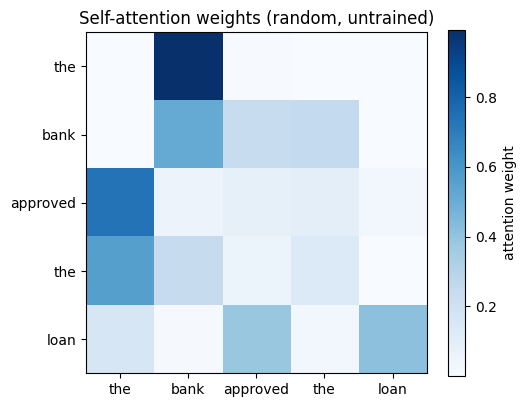

In [19]:
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def self_attention(X, d_k, seed=0):
    rng = np.random.RandomState(seed)
    d_model = X.shape[1]
    W_q = rng.randn(d_model, d_k)
    W_k = rng.randn(d_model, d_k)
    W_v = rng.randn(d_model, d_k)

    Q, K, V = X @ W_q, X @ W_k, X @ W_v
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

sentence = ['the', 'bank', 'approved', 'the', 'loan']
rng = np.random.RandomState(1)
X_tokens = rng.randn(len(sentence), 8)     # random embeddings, one row per token (d_model = 8)

out, attn = self_attention(X_tokens, d_k=4)
print('Output shape:', out.shape, '| Attention matrix shape:', attn.shape)
print('Each row sums to 1:', attn.sum(axis=1).round(3))

plt.figure(figsize=(5.5, 4.5))
plt.imshow(attn, cmap='Blues')
plt.xticks(range(len(sentence)), sentence)
plt.yticks(range(len(sentence)), sentence)
plt.colorbar(label='attention weight')
plt.title('Self-attention weights (random, untrained)')
plt.show()


Row *i* of the matrix shows how strongly token *i* attends to every token in the sentence. In a trained Transformer these weights become meaningful (for instance, "bank" attends to "loan" and resolves to the financial meaning), which is how contextual embeddings differ from static ones.


## 13. Optional: NLTK, spaCy and Hugging Face

These cells run only if the libraries (and their models or data) are installed. To try them locally:

```bash
pip install nltk spacy transformers torch
python -m spacy download en_core_web_sm
```


In [20]:
# NLTK: Porter stemmer (rule-based, works without extra downloads)
try:
    from nltk.stem import PorterStemmer
    ps = PorterStemmer()
    print([ps.stem(w) for w in ['studies', 'studying', 'running', 'happily', 'generously']])
except ImportError:
    print('NLTK not installed; skipping.')


NLTK not installed; skipping.


In [21]:
# spaCy: tokenization, POS tags, lemmas and named entities
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    doc = nlp("Sundar Pichai announced new Google products in Mumbai on Monday.")
    print([(t.text, t.pos_, t.lemma_) for t in doc][:8])
    print([(e.text, e.label_) for e in doc.ents])
except Exception as e:
    print('spaCy or its English model is not available; skipping.', type(e).__name__)


spaCy or its English model is not available; skipping. ModuleNotFoundError


In [22]:
# Hugging Face: a pretrained Transformer sentiment classifier in three lines
try:
    from transformers import pipeline
    clf = pipeline('sentiment-analysis')
    print(clf(["I love learning NLP!", "This tutorial is confusing."]))
except Exception as e:
    print('transformers (or model download) not available; skipping.', type(e).__name__)


transformers (or model download) not available; skipping. ModuleNotFoundError


## Summary

| Stage | What we did |
|---|---|
| Preprocessing | Cleaning, tokenization (word / sentence / BPE), stop words, stemming vs. lemmatization |
| Representation | Bag of Words, n-grams, TF-IDF, co-occurrence embeddings |
| Applications | Search with cosine similarity, sentiment classification, topic modeling |
| Language modeling | Bigram model, smoothing, perplexity |
| Modern NLP | Self-attention, and a pointer to spaCy / Hugging Face |

**Next steps in the bootcamp:** Word2Vec/GloVe with Gensim, RNN/LSTM text classifiers, fine-tuning BERT with Hugging Face, building RAG applications with LLMs, and deploying models as APIs.

The concepts behind each step are explained in `nlp_intro_theory.md`.
